# Australian Road Fatalities — Exploratory Data Analysis

**Data:** BITRE [Australian Road Deaths Database](https://data.gov.au/data/dataset/australian-road-deaths-database) (1989 – Oct 2023, 55,360 fatalities) + ABS quarterly Estimated Resident Population.

**Questions this notebook answers**

1. How has the road toll evolved over 35 years — in absolute terms and per capita?
2. Which states and which demographic groups carry the highest risk?
3. When do fatal crashes happen — time of day, day of week, holiday periods?
4. What do crash characteristics (speed zones, vehicle types) tell us?

Run `python src/download_data.py` and `python src/clean_data.py` first.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = sns.color_palette("deep")
DATA = Path("..") / "data" / "processed"
FIG = Path("..") / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

fat = pd.read_csv(DATA / "fatalities_clean.csv", parse_dates=["crash_month"], low_memory=False)
crashes = pd.read_csv(DATA / "crashes_clean.csv", parse_dates=["crash_month"], low_memory=False)
pop = pd.read_csv(DATA / "erp_state_year.csv")

print(f"{len(fat):,} fatalities | {len(crashes):,} fatal crashes | {fat.year.min()}-{fat.year.max()}")
fat.head(3)

55,360 fatalities | 49,903 fatal crashes | 1989-2023


,crash_id,state,year,month,crash_month,date_key,day_of_week,time,hour,time_of_day,...,remoteness,sa4,lga,road_type,christmas_period,easter_period,gender,age,age_group,road_user
0,20237008,NT,2023,10,2023-10-01,202310,Friday,NaN,NaN,Night,...,NaN,NaN,NaN,NaN,False,False,Female,24.0,17-25,Driver
1,20234009,SA,2023,10,2023-10-01,202310,Saturday,03:00,3.0,Night,...,Outer Regional Australia,Barossa - Yorke - Mid North,Yorke Peninsula,Local Road,False,False,Male,22.0,17-25,Driver
2,20233087,Qld,2023,10,2023-10-01,202310,Saturday,03:00,3.0,Night,...,Inner Regional Australia,Wide Bay,Gympie,Collector Road,False,False,Male,19.0,17-25,Driver


## 1. The long view: a road toll cut by more than half

2023 only runs to October in this extract, so annual charts stop at 2022 (the last complete year).

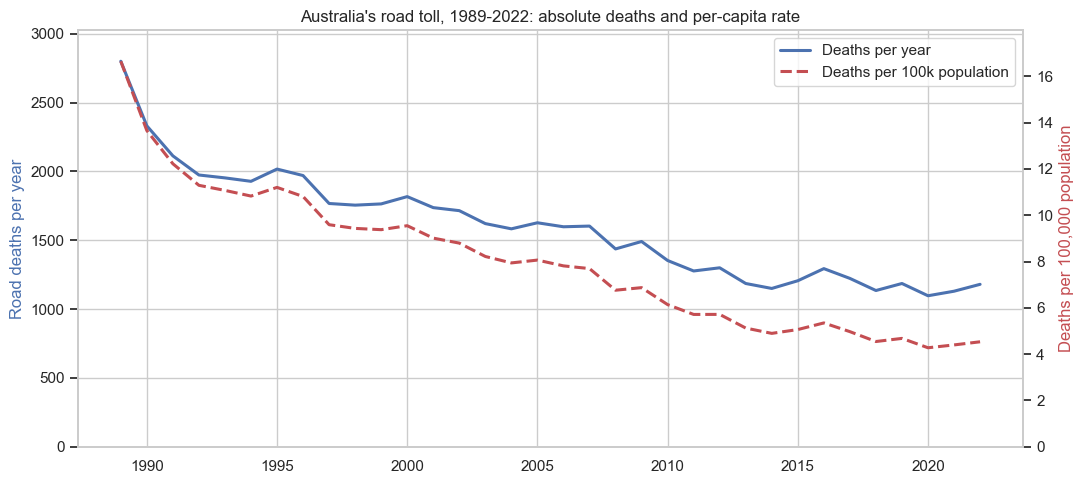

1989: 2,800 deaths (16.7 per 100k)
2022: 1,180 deaths (4.5 per 100k)
Absolute drop: 58% | Per-capita drop: 73%


In [2]:
FULL_YEARS = range(1989, 2023)
annual = fat[fat.year.isin(FULL_YEARS)].groupby("year").size().rename("deaths")
nat_pop = pop.groupby("year")["population"].sum()
annual_rate = (annual / nat_pop * 100_000).rename("per_100k")

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(annual.index, annual.values, color=PALETTE[0], lw=2.2, label="Deaths per year")
ax1.set_ylabel("Road deaths per year", color=PALETTE[0])
ax1.set_ylim(0, annual.max() * 1.08)
ax2 = ax1.twinx()
ax2.plot(annual_rate.index, annual_rate.values, color=PALETTE[3], lw=2.2, ls="--",
         label="Deaths per 100k population")
ax2.set_ylabel("Deaths per 100,000 population", color=PALETTE[3])
ax2.set_ylim(0, annual_rate.max() * 1.08)
ax2.grid(False)
ax1.set_title("Australia's road toll, 1989-2022: absolute deaths and per-capita rate")
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc="upper right")
fig.tight_layout()
fig.savefig(FIG / "01_national_trend.png", dpi=150)
plt.show()

print(f"1989: {annual.loc[1989]:,} deaths ({annual_rate.loc[1989]:.1f} per 100k)")
print(f"2022: {annual.loc[2022]:,} deaths ({annual_rate.loc[2022]:.1f} per 100k)")
print(f"Absolute drop: {1 - annual.loc[2022]/annual.loc[1989]:.0%} | "
      f"Per-capita drop: {1 - annual_rate.loc[2022]/annual_rate.loc[1989]:.0%}")

Deaths fell from ~2,800/year in 1989 to ~1,200/year, while the population grew by ~50% — so the **per-capita rate fell by roughly 70%**. Most of the improvement happened before 2015; the curve has been broadly flat since, which is why recent national road-safety strategies focus on getting the decline moving again.

## 2. States: absolute counts vs per-capita risk

Raw counts follow population size (NSW highest). Per-capita rates tell the real risk story.

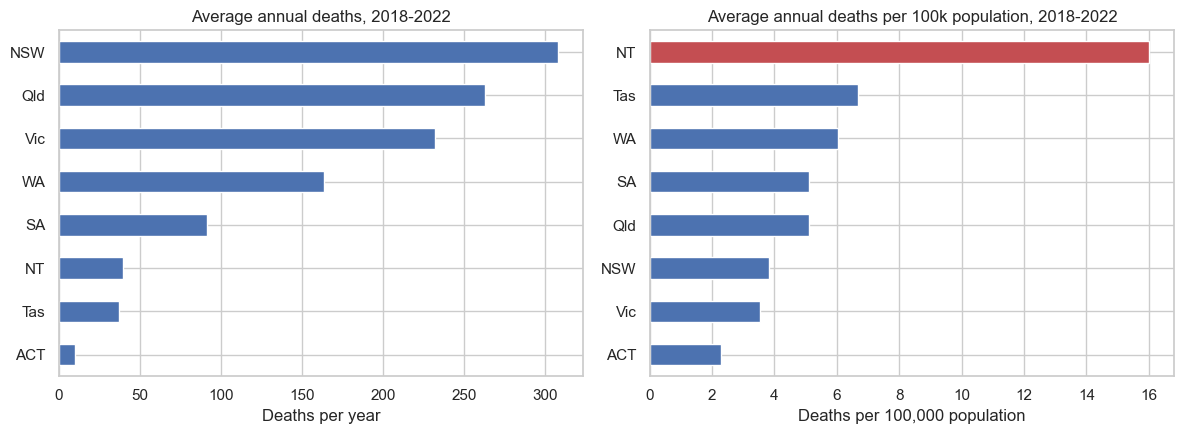

,avg_deaths,avg_per_100k
state,,
NT,39.8,16.01
Tas,37.2,6.66
WA,163.6,6.04
SA,91.4,5.12
Qld,263.2,5.10
NSW,308.0,3.82
Vic,232.2,3.55
ACT,10.2,2.28


In [3]:
RECENT = range(2018, 2023)  # last five complete years
by_state = fat[fat.year.isin(RECENT)].groupby(["state", "year"]).size().rename("deaths").reset_index()
by_state = by_state.merge(pop, on=["state", "year"])
by_state["per_100k"] = by_state.deaths / by_state.population * 100_000
state_summary = (by_state.groupby("state")
                 .agg(avg_deaths=("deaths", "mean"), avg_per_100k=("per_100k", "mean"))
                 .sort_values("avg_per_100k", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
state_summary.sort_values("avg_deaths").avg_deaths.plot.barh(ax=axes[0], color=PALETTE[0])
axes[0].set_title("Average annual deaths, 2018-2022")
axes[0].set_xlabel("Deaths per year")
colors = [PALETTE[3] if s == "NT" else PALETTE[0] for s in state_summary.sort_values("avg_per_100k").index]
state_summary.sort_values("avg_per_100k").avg_per_100k.plot.barh(ax=axes[1], color=colors)
axes[1].set_title("Average annual deaths per 100k population, 2018-2022")
axes[1].set_xlabel("Deaths per 100,000 population")
for ax in axes:
    ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIG / "02_states.png", dpi=150)
plt.show()
state_summary.round(2)

The **Northern Territory's per-capita fatality rate is roughly 4x the national average** — long remote highways, higher speeds and a dispersed population — while the ACT (compact, urban) is the safest. This is the single starkest geographic fact in the dataset and a headline for the dashboard.

## 3. Who dies on the roads: age, gender, road user type

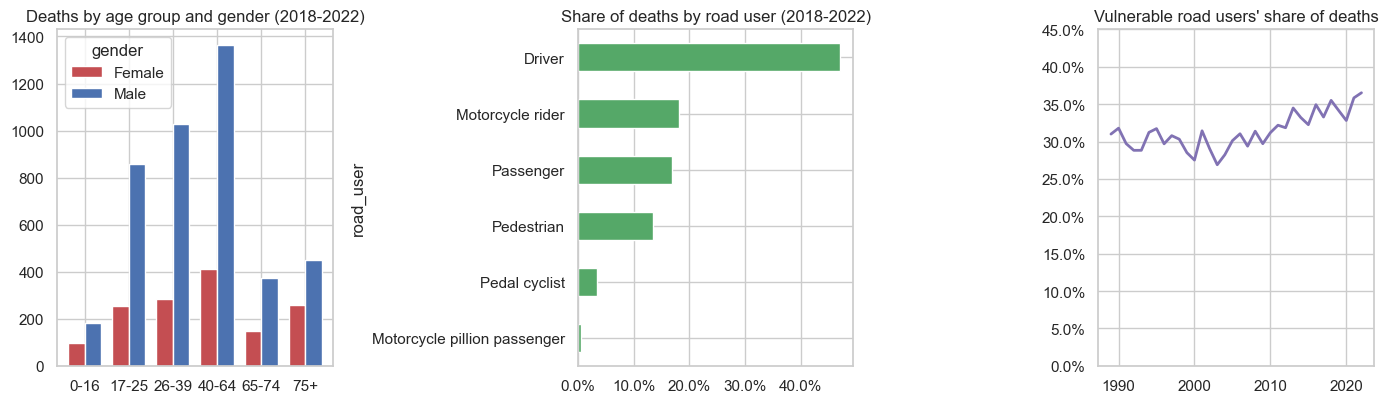

Male share of fatalities (2018-2022): 74%


In [4]:
AGE_ORDER = ["0-16", "17-25", "26-39", "40-64", "65-74", "75+"]
recent = fat[fat.year.isin(RECENT)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

demo = (recent.dropna(subset=["age_group", "gender"])
        .groupby(["age_group", "gender"]).size().unstack())
demo.loc[AGE_ORDER].plot.bar(ax=axes[0], color=[PALETTE[3], PALETTE[0]], width=0.75)
axes[0].set_title("Deaths by age group and gender (2018-2022)")
axes[0].set_xlabel(""); axes[0].tick_params(axis="x", rotation=0)

share = recent.road_user.value_counts(normalize=True).drop("Other/Unknown", errors="ignore")
share.plot.barh(ax=axes[1], color=PALETTE[2])
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Share of deaths by road user (2018-2022)")
axes[1].invert_yaxis()

users = ["Pedestrian", "Motorcycle rider", "Pedal cyclist"]
trend = (fat[fat.year.isin(FULL_YEARS)]
         .assign(vulnerable=fat.road_user.isin(users))
         .groupby("year").vulnerable.mean())
axes[2].plot(trend.index, trend.values, color=PALETTE[4], lw=2)
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[2].set_title("Vulnerable road users' share of deaths")
axes[2].set_ylim(0, 0.45)

fig.tight_layout()
fig.savefig(FIG / "03_demographics.png", dpi=150)
plt.show()

male_share = recent.gender.eq("Male").mean()
print(f"Male share of fatalities (2018-2022): {male_share:.0%}")

Three findings:

- **Men account for ~3 in 4 road deaths**, and the 17–25 male group is the classic high-risk peak despite being a small slice of the population.
- Drivers + passengers are ~65% of deaths, but **pedestrians and motorcyclists together are ~30%** — far above their share of travel.
- The vulnerable-user share has been *rising* slowly as vehicle-occupant safety improved faster (airbags, crashworthiness) than protection for people outside cars.

## 4. When: day of week, hour, and holiday periods

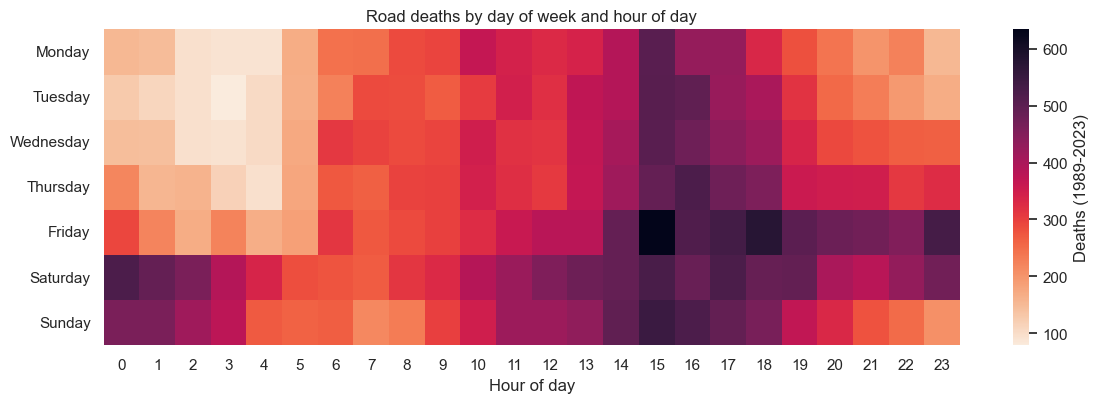

Deaths per day, Christmas period: 4.19
Deaths per day, rest of year:     4.38
Christmas difference: -4%


decade
1980s   -0.168
1990s   -0.017
2000s   -0.075
2010s   -0.030
2020s   -0.009
Name: Christmas uplift, dtype: float64

In [5]:
DOW = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot = (fat.dropna(subset=["hour"])
         .assign(hour=lambda d: d.hour.astype(int))
         .pivot_table(index="day_of_week", columns="hour", values="crash_id", aggfunc="count")
         .reindex(DOW))

fig, ax = plt.subplots(figsize=(12, 4.2))
sns.heatmap(pivot, cmap="rocket_r", ax=ax, cbar_kws={"label": "Deaths (1989-2023)"})
ax.set_title("Road deaths by day of week and hour of day")
ax.set_xlabel("Hour of day"); ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIG / "04_heatmap_dow_hour.png", dpi=150)
plt.show()

# Holiday effect: deaths per day inside vs outside the Christmas window.
# The ARDD dictionary defines the Christmas period as the 12 days from 23 Dec.
years = fat[fat.year.isin(FULL_YEARS)]
xmas_per_day = years[years.christmas_period].groupby("year").size().mean() / 12
normal_per_day = years[~years.christmas_period].groupby("year").size().mean() / 353
print(f"Deaths per day, Christmas period: {xmas_per_day:.2f}")
print(f"Deaths per day, rest of year:     {normal_per_day:.2f}")
print(f"Christmas difference: {xmas_per_day / normal_per_day - 1:+.0%}")

# Has that always been true? Compare by decade.
decade = (years.year // 10 * 10).astype(str) + "s"
per_day = (years.assign(decade=decade)
           .groupby(["decade", "christmas_period"]).size().unstack())
per_day = per_day.div([353 * 10, 12 * 10], axis=1)  # approx. days per decade
per_day.columns = ["rest of year", "Christmas period"]
(per_day["Christmas period"] / per_day["rest of year"] - 1).rename("Christmas uplift").round(3)

The heatmap shows two danger zones: **weekend nights** (Fri/Sat 20:00–03:00, the alcohol-and-fatigue signature) and **weekday afternoon peaks (~15:00–17:00)**.

The Christmas result is a genuine surprise worth calling out: **the holiday period's daily fatality rate is no higher than the rest of the year** in the recent decades, despite heavier traffic — the era of double-demerit points and blitz enforcement coincides with the Christmas "excess" disappearing. A good dashboard should bust this myth rather than repeat it.

## 5. Crash characteristics: speed zones and heavy vehicles

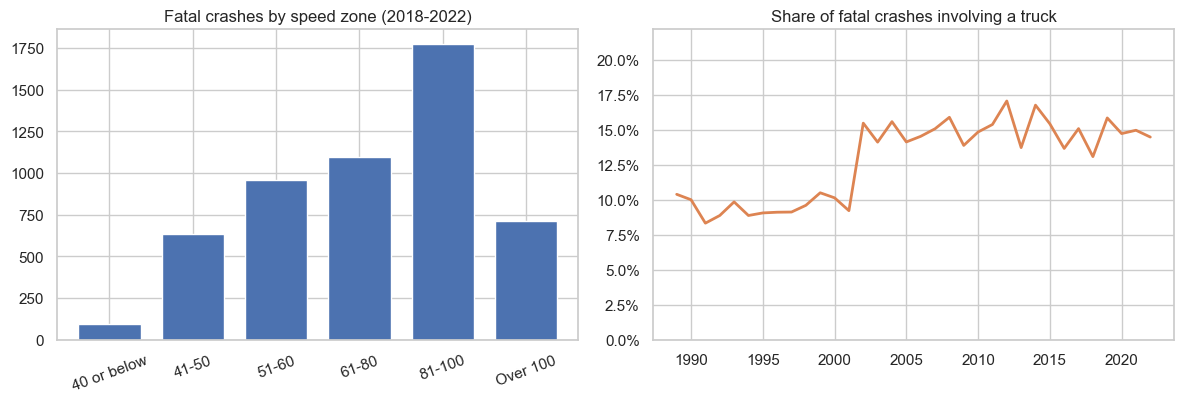

Fatal crashes with more than one death: 8.5%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ZONES = ["40 or below", "41-50", "51-60", "61-80", "81-100", "Over 100"]
zone = crashes[crashes.year.isin(RECENT)].speed_zone.value_counts().reindex(ZONES)
zone.plot.bar(ax=axes[0], color=PALETTE[0], width=0.75)
axes[0].set_title("Fatal crashes by speed zone (2018-2022)")
axes[0].tick_params(axis="x", rotation=20); axes[0].set_xlabel("")

truck = (crashes[crashes.year.isin(FULL_YEARS)]
         .assign(truck=lambda d: d[["heavy_rigid_truck_involved", "articulated_truck_involved"]]
                 .eq("Yes").any(axis=1))
         .groupby("year").truck.mean())
axes[1].plot(truck.index, truck.values, color=PALETTE[1], lw=2)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Share of fatal crashes involving a truck")
axes[1].set_ylim(0, truck.max() * 1.3)

fig.tight_layout()
fig.savefig(FIG / "05_crash_characteristics.png", dpi=150)
plt.show()

multi = crashes.multiple_fatalities.mean()
print(f"Fatal crashes with more than one death: {multi:.1%}")

**High-speed zones dominate**: 81–100 km/h zones (mostly rural highways) account for the largest share of fatal crashes — rural roads are where speed, distance from trauma care, and single-vehicle run-off crashes combine. About 8–9% of fatal crashes kill more than one person; that severity question is the classification target in `02_modeling.ipynb`.

## Key takeaways

| # | Finding | Dashboard/model implication |
|---|---------|------------------------------|
| 1 | Per-capita road deaths fell ~70% since 1989, but progress has stalled since ~2015 | Headline KPI + trend visual |
| 2 | NT's per-capita rate is ~4x the national average | Per-capita map, not raw counts |
| 3 | Males ~75% of deaths; 17–25 males the classic peak | Demographic drill-down page |
| 4 | Weekend nights are the danger window; the Christmas period is *not* deadlier per day than the rest of the year | Time heatmap; myth-busting KPI card |
| 5 | 81–100 km/h rural zones dominate fatal crashes | Speed-zone visual; rural road investment case |